In [79]:
import pandas as pd
import numpy as np

In [80]:
df = pd.read_csv(r"/content/StudentsPerformance.csv")

# About Data

In [225]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [82]:
#df.shape

(1000, 8)

In [83]:
#df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


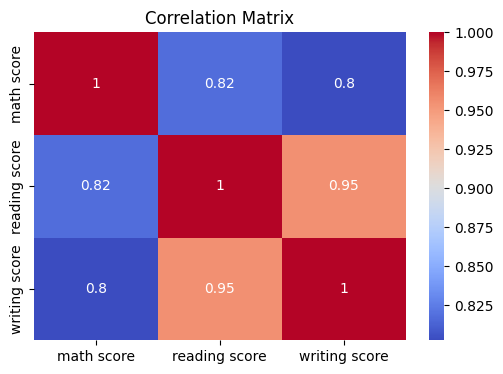

In [84]:
numeric_cols = ['math score', 'reading score', 'writing score']

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Data Cleaning

In [85]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [86]:
df.duplicated().sum()

np.int64(0)

# Graphical Analysis

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

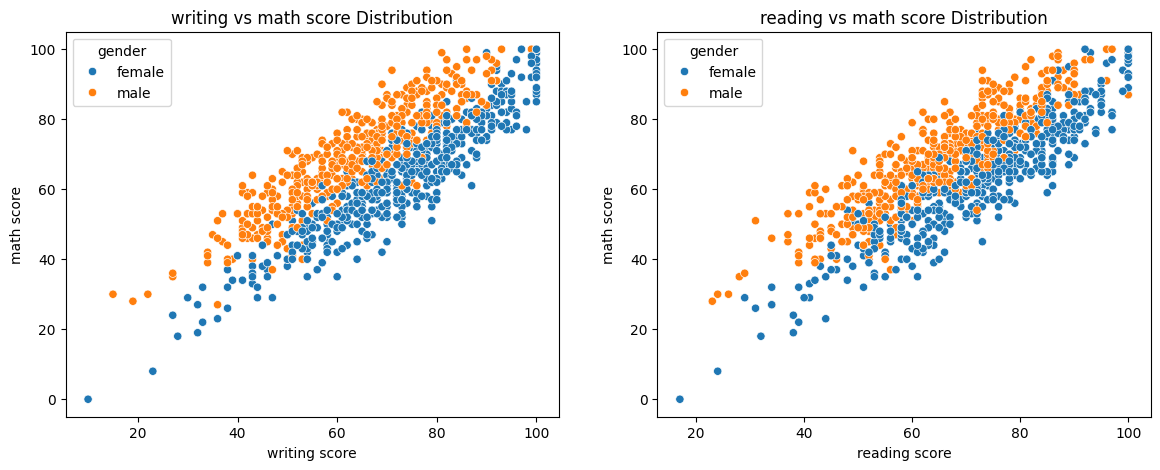

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df,
    x='writing score',
    y='math score',
    hue='gender',
    ax=axes[0]
)
axes[0].set_title('writing vs math score Distribution')

sns.scatterplot(
    data=df,
    x='reading score',
    y='math score',
    hue='gender',
    ax=axes[1]
)
axes[1].set_title('reading vs math score Distribution')

plt.show()

In [89]:
#Orange points (male) have higher math score for same writing and reading score comperitively Blue points(female)

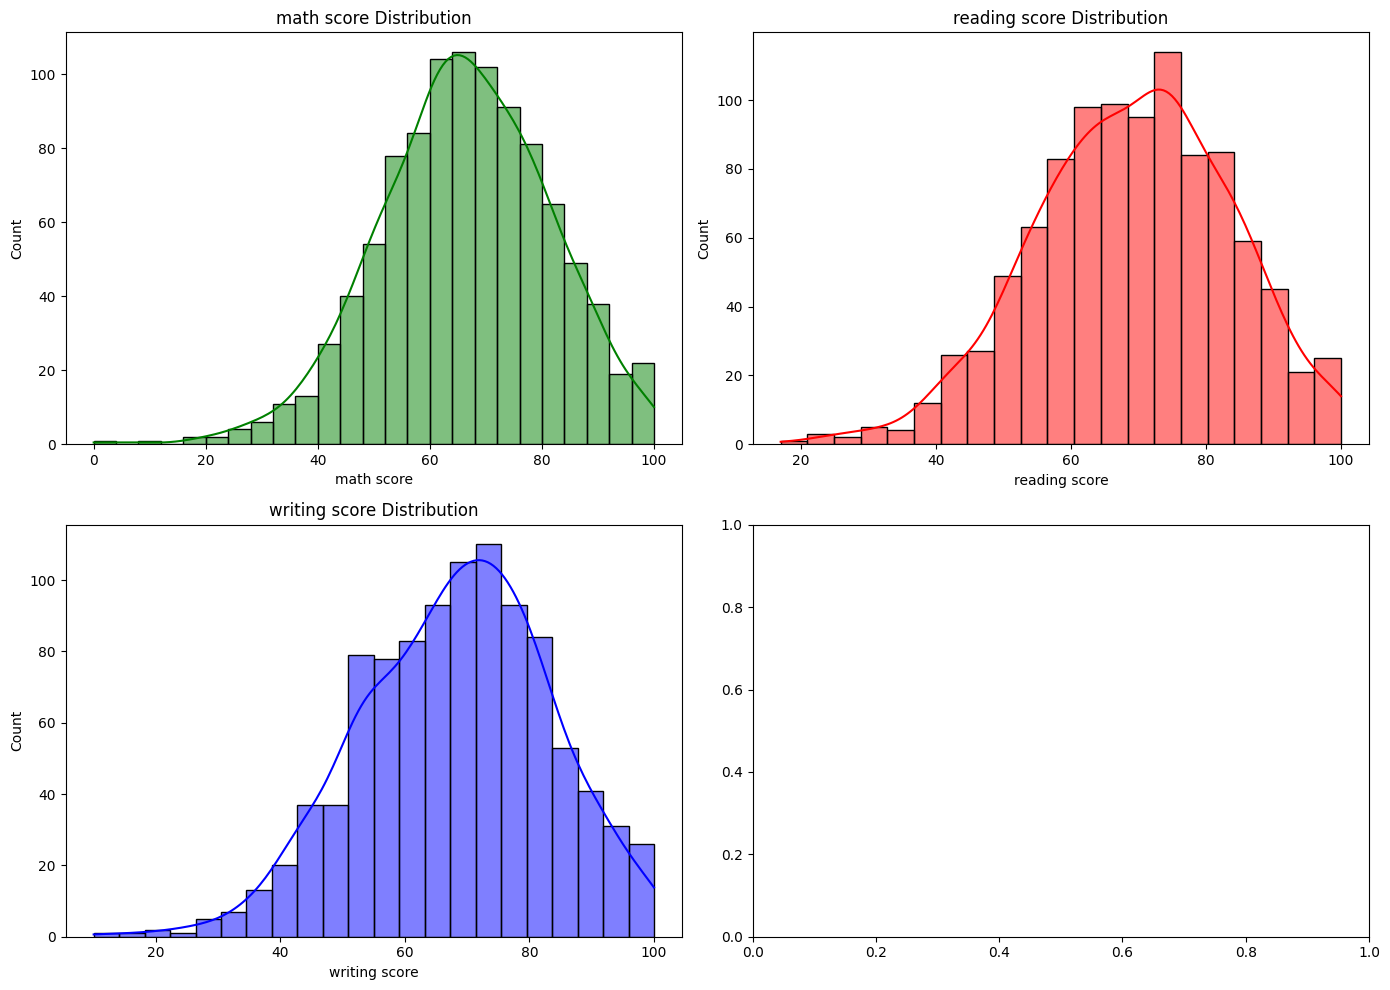

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['math score'], kde=True, color='green', ax=axes[0, 0])
axes[0, 0].set_title('math score Distribution')

sns.histplot(df['reading score'], kde=True, color='red', ax=axes[0, 1])
axes[0, 1].set_title('reading score Distribution')

sns.histplot(df['writing score'], kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].set_title('writing score Distribution')

plt.tight_layout()
plt.show()

# EDA

In [91]:
# outlier removal

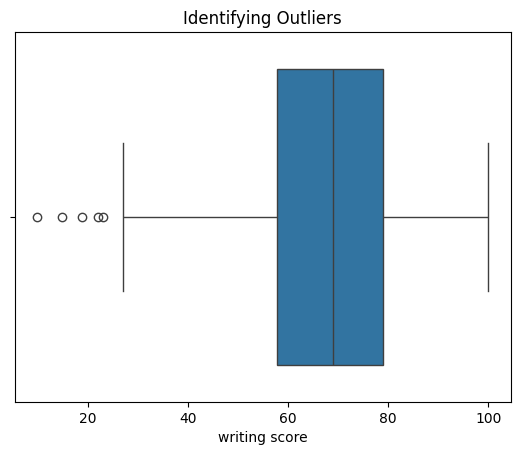

In [92]:
sns.boxplot(x=df['writing score'])
plt.title('Identifying Outliers')
plt.show()

In [93]:
mean = float(df['reading score'].mean())
mean2 = float(df['writing score'].mean())

In [94]:
std = df['reading score'].std()
std2 = df['writing score'].std()

In [95]:
mean, std

(69.169, 14.60019193725222)

In [96]:
mean2, std2

(68.054, 15.195657010869642)

In [141]:
reading_z = (df['reading score'] - mean) / std
writing_z = (df['writing score'] - mean2) / std2

df_new = df[
    (reading_z >= -3) &
    (reading_z <= 3) &
    (writing_z >= -3) &
    (writing_z <= 3)
]

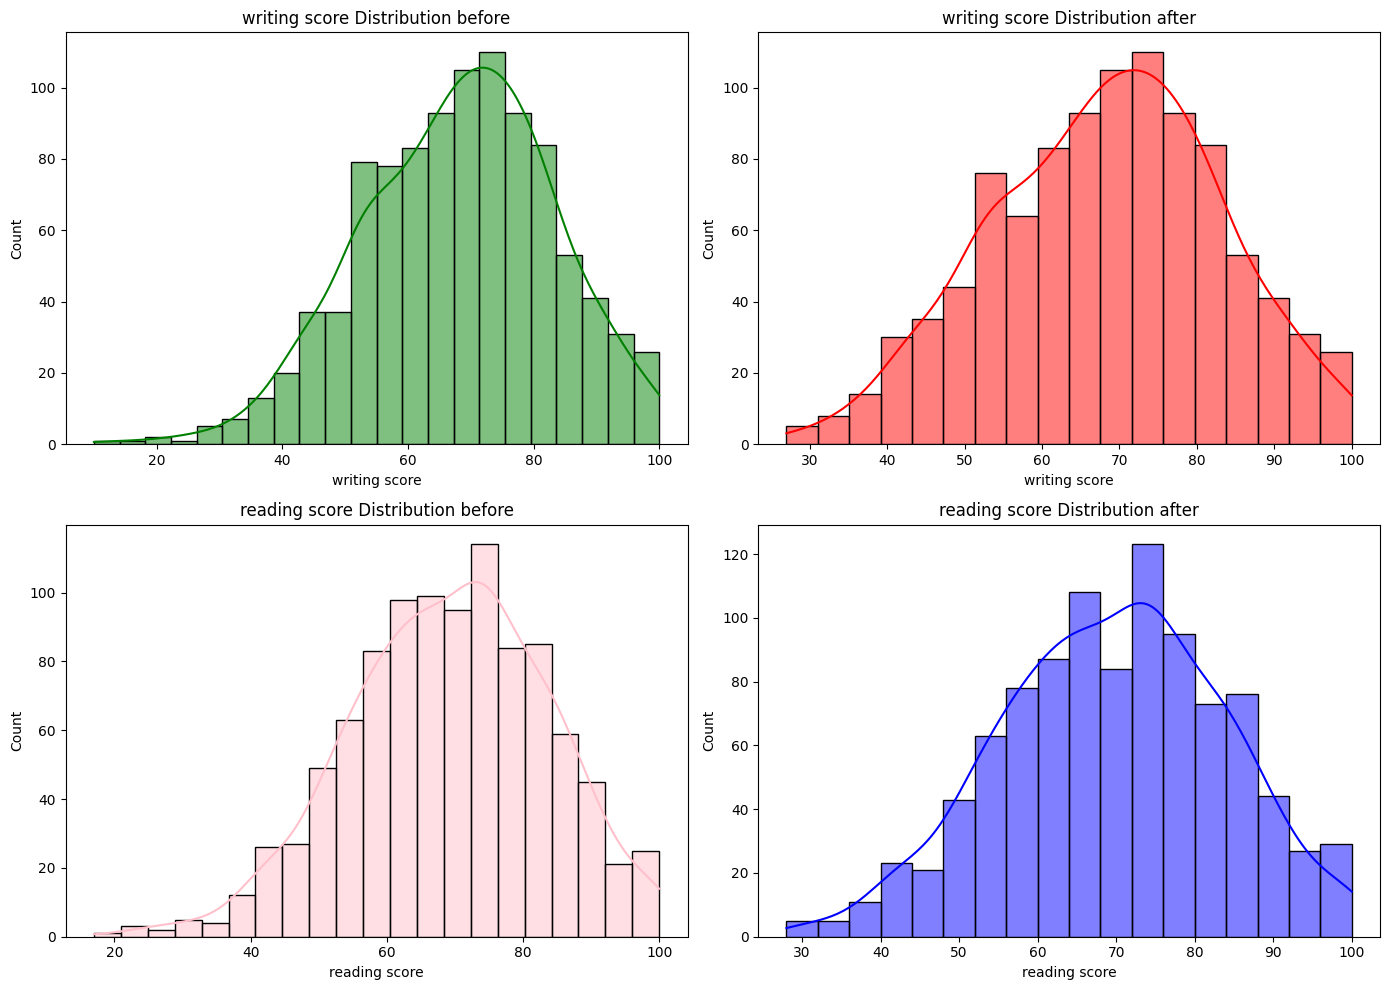

In [142]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['writing score'], kde=True, color='green', ax=axes[0, 0])
axes[0, 0].set_title('writing score Distribution before')

sns.histplot(df_new['writing score'], kde=True, color='red', ax=axes[0, 1])
axes[0, 1].set_title('writing score Distribution after')

sns.histplot(df['reading score'], kde=True, color='pink', ax=axes[1, 0])
axes[1, 0].set_title('reading score Distribution before')

sns.histplot(df_new['reading score'], kde=True, color='blue', ax=axes[1, 1])
axes[1, 1].set_title('reading score Distribution after')

plt.tight_layout()
plt.show()

# Train Test Split

In [143]:
X = df_new.drop(['math score'], axis=1)
y = df_new['math score']

In [147]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [148]:
X_train.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
913,female,group C,bachelor's degree,free/reduced,completed,62,66
929,female,group C,some high school,free/reduced,none,56,51
978,male,group D,high school,standard,completed,41,48
769,male,group A,some college,free/reduced,none,60,57
915,female,group E,some college,standard,none,70,66


In [149]:
y_train.head()

,math score
913,47
929,48
978,55
769,58
915,68


In [150]:
#encoding of columns('gender','race/ethnicity','parental level of education','lunch','test preparation course')

In [151]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [152]:

trf = ColumnTransformer(transformers=[
    ('trf' ,OneHotEncoder(drop='first', sparse_output=False), [0,1,2,3,4]),
],remainder='passthrough')

In [153]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

# Model Training

In [154]:
#LinearRegression

In [155]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [156]:
clf = LinearRegression()

In [157]:
clf.fit(X_train_transformed,y_train)
y_pred = clf.predict(X_test_transformed)

In [158]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.851748065066967
MSE: 23.70272556455494
R2 Score: 0.8972427592116328


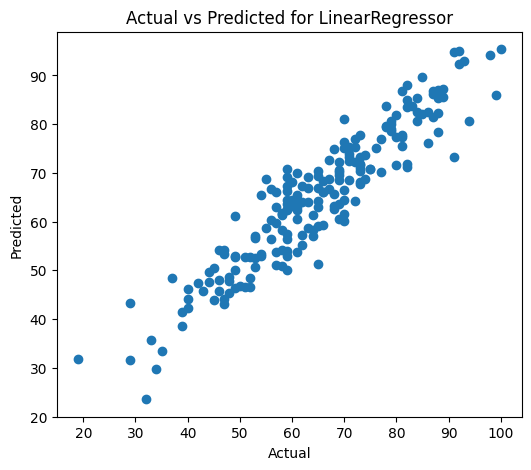

In [220]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted for LinearRegressor")
plt.show()

In [159]:
#DecisionTree

In [160]:
from sklearn.tree import DecisionTreeRegressor

In [179]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=40,
    min_samples_leaf=7
)
dt.fit(X_train_transformed, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=7, min_samples_split=40)

In [180]:
y_pred_dt = dt.predict(X_test_transformed)
r2_score(y_test,y_pred_dt)

0.833805509932116

In [181]:
#GradientBoost

In [182]:
from sklearn.ensemble import GradientBoostingRegressor

In [193]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.9,
    random_state=42
)
gbr.fit(X_train_transformed, y_train)

GradientBoostingRegressor(max_depth=4, random_state=42, subsample=0.9)

In [194]:
y_pred_gbr = gbr.predict(X_test_transformed)
r2_score(y_test,y_pred_gbr)

0.8749911518571035

In [195]:
#BaggingRegressor

In [196]:
from sklearn.ensemble import BaggingRegressor

In [197]:
bag = BaggingRegressor(
    estimator=LinearRegression(),
    n_estimators=1000,
    bootstrap=True,
    random_state=42
)
bag.fit(X_train_transformed,y_train)

BaggingRegressor(estimator=LinearRegression(), n_estimators=1000,
                 random_state=42)

In [198]:
y_pred = bag.predict(X_test_transformed)
print(r2_score(y_test, y_pred))

0.8972155109105265


In [128]:
#RandomForest

In [199]:
from sklearn.ensemble import RandomForestRegressor

In [200]:
rf = RandomForestRegressor(n_estimators=1000, max_samples=0.35)
rf.fit(X_train_transformed, y_train)

RandomForestRegressor(max_samples=0.35, n_estimators=1000)

In [201]:
y_pred = rf.predict(X_test_transformed)
r2_score(y_test, y_pred)

0.8743298426562885

In [202]:
importance = rf.feature_importances_
importance

array([0.12114619, 0.00598625, 0.00713721, 0.0071537 , 0.00993714,
       0.00562852, 0.0063951 , 0.00213246, 0.00721302, 0.00550306,
       0.01879941, 0.0125542 , 0.55539431, 0.23501944])

In [203]:
feature_names = trf.get_feature_names_out()

for name, importance in zip(feature_names, rf.feature_importances_):
    print(name, round(importance,4))

trf__gender_male 0.1211
trf__race/ethnicity_group B 0.006
trf__race/ethnicity_group C 0.0071
trf__race/ethnicity_group D 0.0072
trf__race/ethnicity_group E 0.0099
trf__parental level of education_bachelor's degree 0.0056
trf__parental level of education_high school 0.0064
trf__parental level of education_master's degree 0.0021
trf__parental level of education_some college 0.0072
trf__parental level of education_some high school 0.0055
trf__lunch_standard 0.0188
trf__test preparation course_none 0.0126
remainder__reading score 0.5554
remainder__writing score 0.235


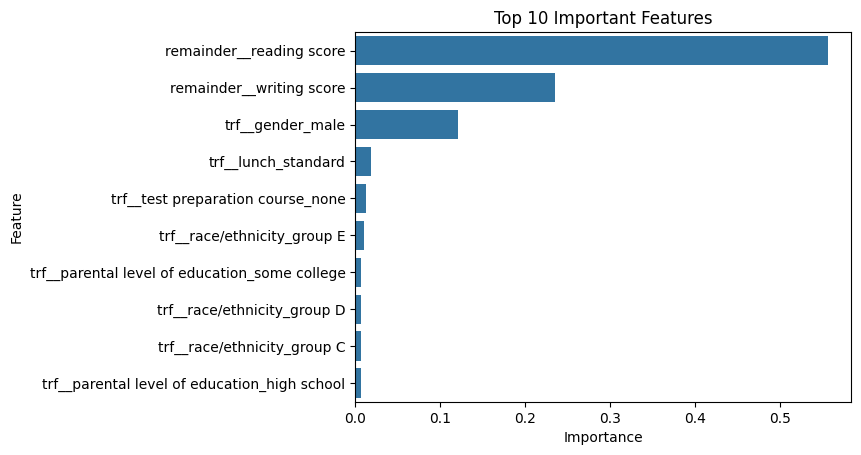

In [217]:
importance_df = pd.DataFrame({
    "Feature": trf.get_feature_names_out(),
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [204]:
#XGBoost

In [205]:
from xgboost import XGBRegressor

In [206]:
xgb = XGBRegressor(
    n_estimators=1000,     # Number of trees
    max_depth=5,           # Tree depth
    learning_rate=0.01,    # Learning speed
    subsample=0.85,        # Row sampling
)
xgb.fit(X_train_transformed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [207]:
y_pred = xgb.predict(X_test_transformed)
r2_score(y_test, y_pred)

0.8689273595809937

Linear Regresson From Scratch

In [221]:
class mera_lr:

  def __init__(self):
    self.coef=None
    self.intercept=None
  def fit(self,X_train_transformed,y_train):
    X_train_transformed = np.insert(X_train_transformed, 0, 1, axis=1)

    beta = np.linalg.inv(np.dot(X_train_transformed.T,X_train_transformed)).dot(X_train_transformed.T).dot(y_train)
    self.intercept=beta[0]
    self.coef=beta[1:]

  def predict(self, X_test_transformed):
    y_pred1=np.dot(X_test_transformed,self.coef)+self.intercept
    return y_pred1

In [222]:
lr = mera_lr()
lr.fit(X_train_transformed,y_train)

In [223]:
y_pred_mera_lr = lr.predict(X_test_transformed)
r2_score(y_test,y_pred_mera_lr)

0.8972427592116389

In [224]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Gradient Boosting","Bagging","Random Forest","XGBoost"],
    "R2 Score": [
        r2_score(y_test, clf.predict(X_test_transformed)),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_gbr),
        r2_score(y_test, bag.predict(X_test_transformed)),
        r2_score(y_test, rf.predict(X_test_transformed)),
        r2_score(y_test, xgb.predict(X_test_transformed))
    ]
})

results.sort_values("R2 Score", ascending=False)

,Model,R2 Score
0,Linear Regression,0.897243
3,Bagging,0.897216
2,Gradient Boosting,0.874991
4,Random Forest,0.874330
5,XGBoost,0.868927
1,Decision Tree,0.833806


# Conclusion

- Reading score and writing score are the strongest predictors of math score.
- Correlation analysis showed a strong positive relationship between academic scores.
- Multiple machine learning models were trained and compared.
- Ensemble models such as Random Forest and XGBoost achieved better performance than simple Linear Regression.
- Feature importance analysis revealed that reading and writing scores contribute most to predicting math score.
- This project demonstrates the complete machine learning workflow including EDA, preprocessing, model building, and evaluation.